# 02 - RF-DETR Nano Training & Evaluation

Training controllato di RF-DETR Nano sul dataset SportsMOT Basketball.

Obiettivi:
- eseguire il fine-tuning per più epoche;
- monitorare training loss e validation loss;
- valutare mAP, precision e recall sul validation set;
- salvare automaticamente il miglior checkpoint;
- confrontare i risultati con lo smoke test da 1 epoca.

In [1]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA disponibile:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA PyTorch:", torch.version.cuda)

PyTorch: 2.11.0+cu128
CUDA disponibile: True
GPU: Tesla T4
CUDA PyTorch: 12.8


In [3]:
!nvidia-smi

Tue Sep 29 18:06:02 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8             13W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

Installazione RF-DETR

In [4]:
!pip install -q "rfdetr[train,loggers]==1.10.1"

In [5]:
from pathlib import Path

DRIVE_ROOT = Path("/content/drive/MyDrive/basketball-thesis")

DATASET_ZIP = DRIVE_ROOT / "datasets" / "sportsmot_basketball_coco.zip"

DATA_ROOT = Path("/content/data")
DATASET_ROOT = DATA_ROOT / "sportsmot_coco"

CHECKPOINT_DIR = DRIVE_ROOT / "checkpoints" / "rfdetr_nano_10epochs"

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

print("Dataset ZIP:", DATASET_ZIP)
print("Dataset locale:", DATASET_ROOT)
print("Checkpoint:", CHECKPOINT_DIR)

Dataset ZIP: /content/drive/MyDrive/basketball-thesis/datasets/sportsmot_basketball_coco.zip
Dataset locale: /content/data/sportsmot_coco
Checkpoint: /content/drive/MyDrive/basketball-thesis/checkpoints/rfdetr_nano_10epochs


In [6]:
import shutil

if DATASET_ROOT.exists():
    shutil.rmtree(DATASET_ROOT)

print("Cartella precedente rimossa.")

Cartella precedente rimossa.


In [7]:
!mkdir -p /content/data
!unzip -q /content/drive/MyDrive/basketball-thesis/datasets/sportsmot_basketball_coco.zip -d /content/data

In [8]:
train_dir = DATASET_ROOT / "train"
valid_dir = DATASET_ROOT / "valid"

print("Train presente:", train_dir.exists())
print("Valid presente:", valid_dir.exists())

train_images = list(train_dir.glob("*.jpg"))
valid_images = list(valid_dir.glob("*.jpg"))

print("Train images:", len(train_images))
print("Valid images:", len(valid_images))

print(
    "Train annotations:",
    (train_dir / "_annotations.coco.json").exists()
)

print(
    "Valid annotations:",
    (valid_dir / "_annotations.coco.json").exists()
)

Train presente: True
Valid presente: True
Train images: 12384
Valid images: 12557
Train annotations: True
Valid annotations: True


In [9]:
import json

with open(train_dir / "_annotations.coco.json") as f:
    train_coco = json.load(f)

with open(valid_dir / "_annotations.coco.json") as f:
    valid_coco = json.load(f)

print("TRAIN")
print("Immagini:", len(train_coco["images"]))
print("Annotazioni:", len(train_coco["annotations"]))
print("Categorie:", train_coco["categories"])

print()

print("VALID")
print("Immagini:", len(valid_coco["images"]))
print("Annotazioni:", len(valid_coco["annotations"]))
print("Categorie:", valid_coco["categories"])

TRAIN
Immagini: 12384
Annotazioni: 108848
Categorie: [{'id': 1, 'name': 'basketball_player', 'supercategory': 'person'}]

VALID
Immagini: 12557
Annotazioni: 118825
Categorie: [{'id': 1, 'name': 'basketball_player', 'supercategory': 'person'}]


## Configurazione dell'esperimento

Modello:
- RF-DETR Nano

Dataset:
- SportsMOT Basketball
- train: 12.384 immagini
- validation: 12.557 immagini
- classe: basketball_player

Training:
- epochs: 10
- learning rate: 1e-4
- batch size: automatico
- mixed precision: gestita da RF-DETR / PyTorch Lightning
- validation loss: abilitata
- metriche COCO calcolate a ogni epoca
- checkpoint salvati su Google Drive

Inizializzazione del modello

In [10]:
from rfdetr import RFDETRNano

model = RFDETRNano()

print("RF-DETR Nano inizializzato.")

[2026-09-29 18:09:19] [INFO] rf-detr - Downloading pretrained weights for /root/.roboflow/models/rf-detr-nano.pth


/root/.roboflow/models/rf-detr-nano.pth:   0%|          | 0.00/349M [00:00<?, ?iB/s]

[2026-09-29 18:09:27] [INFO] rf-detr - MD5 validation successful for /root/.roboflow/models/rf-detr-nano.pth


[2026-09-29 18:09:27] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-09-29 18:09:27] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-09-29 18:09:29] [INFO] rf-detr - File /root/.roboflow/models/rf-detr-nano.pth already exists with correct MD5 hash.
RF-DETR Nano inizializzato.


Training principale

In [12]:
from pathlib import Path

CHECKPOINT_DIR = Path(
    "/content/drive/MyDrive/basketball-thesis/checkpoints/rfdetr_nano_10epochs"
)

for f in sorted(CHECKPOINT_DIR.glob("*")):
    print(f.name)

checkpoint_0.ckpt
checkpoint_1.ckpt
checkpoint_2.ckpt
checkpoint_3.ckpt
checkpoint_4.ckpt
checkpoint_5.ckpt
checkpoint_6.ckpt
checkpoint_best_ema.pth
events.out.tfevents.1790604242.4b3964ec18e0.964.0
events.out.tfevents.1790604468.4b3964ec18e0.964.1
events.out.tfevents.1790705410.0e50ccf2452a.2019.0
hparams.yaml
metrics.csv


In [13]:
from rfdetr import RFDETRNano

model = RFDETRNano()

RESUME_CHECKPOINT = CHECKPOINT_DIR / "checkpoint_6.ckpt"

model.train(
    dataset_dir=str(DATASET_ROOT),
    epochs=10,
    batch_size="auto",
    lr=1e-4,
    output_dir=str(CHECKPOINT_DIR),
    progress_bar="tqdm",
    compute_val_loss=True,
    seed=42,
    checkpoint_interval=1,
    resume=str(RESUME_CHECKPOINT),
)

[2026-09-29 18:14:55] [INFO] rf-detr - File /root/.roboflow/models/rf-detr-nano.pth already exists with correct MD5 hash.


[2026-09-29 18:14:55] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-09-29 18:14:55] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-09-29 18:14:56] [INFO] rf-detr - File /root/.roboflow/models/rf-detr-nano.pth already exists with correct MD5 hash.


[2026-09-29 18:14:59] [WARNING] rf-detr - [auto-batch] 1/465 trainable params received no gradient from the synthetic probe batch; their optimizer state is not modeled, so the returned batch size may be too permissive.


[2026-09-29 18:15:23] [INFO] rf-detr - [auto-batch] Applied EMA headroom (0.70): safe_micro_batch=9
[2026-09-29 18:15:23] [INFO] rf-detr - [auto-batch] device=Tesla T4 world_size=1 segmentation=False probe_resolution=544 max_targets_per_image=100
[2026-09-29 18:15:23] [INFO] rf-detr - [auto-batch] safe_micro_batch=9 grad_accum_steps=2 effective_batch_per_device=18 global_effective_batch=18
[2026-09-29 18:15:23] [INFO] rf-detr - [auto-batch] This probe estimates train-step-safe micro-batch only.
[2026-09-29 18:15:23] [INFO] rf-detr - [auto-batch] Validation/test (especially segmentation mask eval) may require more memory.
[2026-09-29 18:15:23] [INFO] rf-detr - [auto-batch] resolved train config: batch_size=9 grad_accum_steps=2 effective_batch_size=18


...

Output()

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.


[2026-09-29 19:55:23] [INFO] rf-detr - Best total checkpoint saved from EMA (regular=0.0000, ema=0.7104)


In [14]:
files = sorted(CHECKPOINT_DIR.glob("*"))

print("File prodotti:")
for file in files:
    print(file.name)

File prodotti:
checkpoint_0.ckpt
checkpoint_1.ckpt
checkpoint_2.ckpt
checkpoint_3.ckpt
checkpoint_4.ckpt
checkpoint_5.ckpt
checkpoint_6.ckpt
checkpoint_7.ckpt
checkpoint_8.ckpt
checkpoint_9.ckpt
checkpoint_best_ema.pth
checkpoint_best_total.pth
events.out.tfevents.1790604242.4b3964ec18e0.964.0
events.out.tfevents.1790604468.4b3964ec18e0.964.1
events.out.tfevents.1790705410.0e50ccf2452a.2019.0
events.out.tfevents.1790705727.0e50ccf2452a.2019.1
hparams.yaml
last_ema.pth
metrics.csv
training_config.json


In [15]:
metrics_files = list(CHECKPOINT_DIR.rglob("metrics.csv"))

print("Metrics trovati:")
for f in metrics_files:
    print(f)

Metrics trovati:
/content/drive/MyDrive/basketball-thesis/checkpoints/rfdetr_nano_10epochs/metrics.csv


In [16]:
import pandas as pd

METRICS_FILE = metrics_files[0]

df = pd.read_csv(METRICS_FILE)

print(df.columns.tolist())
df.tail()

['epoch', 'step', 'train/cardinality_error', 'train/cardinality_error_0', 'train/cardinality_error_enc', 'train/class_error', 'train/loss', 'train/loss_bbox', 'train/loss_bbox_aux', 'train/loss_ce', 'train/loss_ce_aux', 'train/loss_giou', 'train/loss_giou_aux', 'train/lr', 'train/lr_max', 'train/lr_min', 'val/F1', 'val/cardinality_error', 'val/cardinality_error_0', 'val/cardinality_error_enc', 'val/class_error', 'val/ema_mAP_50', 'val/ema_mAP_50_95', 'val/ema_mAP_75', 'val/ema_mAR', 'val/loss', 'val/loss_bbox', 'val/loss_bbox_0', 'val/loss_bbox_enc', 'val/loss_ce', 'val/loss_ce_0', 'val/loss_ce_enc', 'val/loss_giou', 'val/loss_giou_0', 'val/loss_giou_enc', 'val/mAP_50', 'val/mAP_50_95', 'val/mAP_75', 'val/mAR', 'val/precision', 'val/recall']


,epoch,step,train/cardinality_error,train/cardinality_error_0,train/cardinality_error_enc,train/class_error,train/loss,train/loss_bbox,train/loss_bbox_aux,train/loss_ce,...,val/loss_ce_enc,val/loss_giou,val/loss_giou_0,val/loss_giou_enc,val/mAP_50,val/mAP_50_95,val/mAP_75,val/mAR,val/precision,val/recall
179,9,7349,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
180,9,7399,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
181,9,7449,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
182,9,7481,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.489908,0.161491,0.167507,0.186806,0.982641,0.704014,0.808029,0.774549,0.97666,0.959293
183,9,7481,89.644699,88.692993,89.383072,-2.217847e-07,2.569587,0.023334,0.0509,0.41081,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Pulizia epoca

In [17]:
metric_cols = [
    col for col in df.columns
    if any(
        key in col
        for key in [
            "epoch",
            "train/loss",
            "val/loss",
            "mAP",
            "Precision",
            "Recall",
            "F1",
        ]
    )
]

df_metrics = df[metric_cols]

df_metrics.tail(20)

,epoch,train/loss,train/loss_bbox,train/loss_bbox_aux,train/loss_ce,train/loss_ce_aux,train/loss_giou,train/loss_giou_aux,val/F1,val/ema_mAP_50,...,val/loss_bbox_enc,val/loss_ce,val/loss_ce_0,val/loss_ce_enc,val/loss_giou,val/loss_giou_0,val/loss_giou_enc,val/mAP_50,val/mAP_50_95,val/mAP_75
164,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
165,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
166,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.966237,0.982511,...,0.029098,0.443025,0.467107,0.496237,0.161197,0.167537,0.188856,0.982511,0.705930,0.811515
167,8,2.604722,0.023479,0.052093,0.414419,0.899082,0.144786,0.311894,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
168,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
169,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
170,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
171,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
172,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
173,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Grafico Training Loss

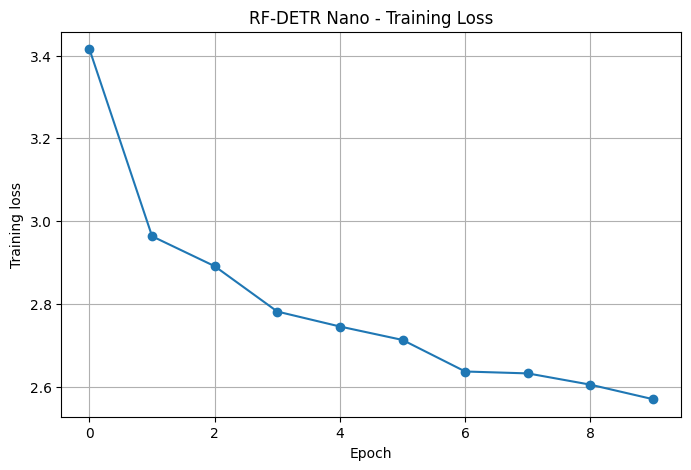

In [18]:
import matplotlib.pyplot as plt

if "train/loss" in df.columns:
    train_loss = df.dropna(subset=["train/loss"])

    plt.figure(figsize=(8, 5))
    plt.plot(
        train_loss["epoch"],
        train_loss["train/loss"],
        marker="o"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Training loss")
    plt.title("RF-DETR Nano - Training Loss")
    plt.grid(True)
    plt.show()

Grafico Validation Loss

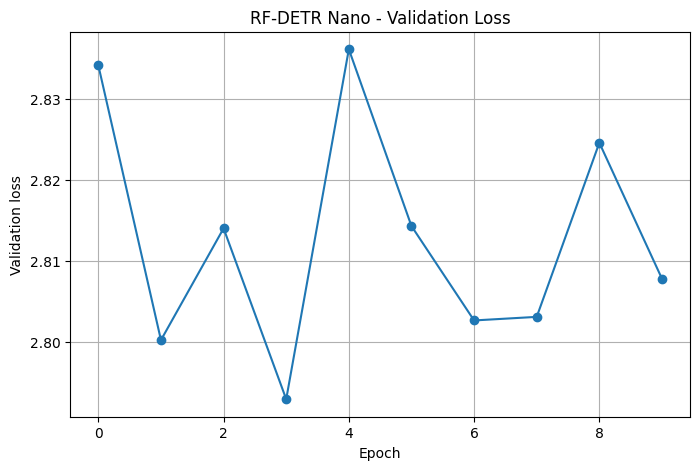

In [19]:
if "val/loss" in df.columns:
    val_loss = df.dropna(subset=["val/loss"])

    plt.figure(figsize=(8, 5))
    plt.plot(
        val_loss["epoch"],
        val_loss["val/loss"],
        marker="o"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Validation loss")
    plt.title("RF-DETR Nano - Validation Loss")
    plt.grid(True)
    plt.show()

Grafico mAP@50:95

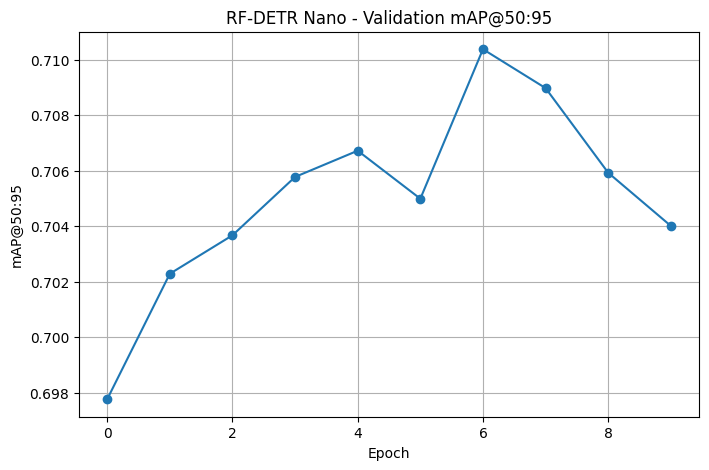

In [20]:
map_col = "val/mAP_50_95"

if map_col in df.columns:
    map_df = df.dropna(subset=[map_col])

    plt.figure(figsize=(8, 5))
    plt.plot(
        map_df["epoch"],
        map_df[map_col],
        marker="o"
    )

    plt.xlabel("Epoch")
    plt.ylabel("mAP@50:95")
    plt.title("RF-DETR Nano - Validation mAP@50:95")
    plt.grid(True)
    plt.show()

Grafico mAP@50

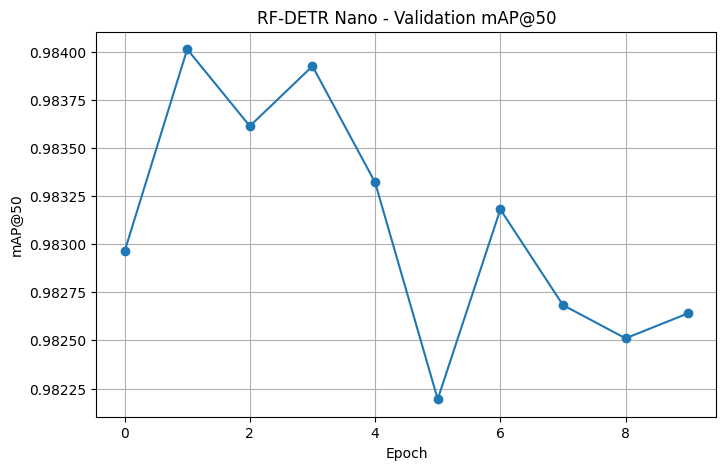

In [21]:
map50_col = "val/mAP_50"

if map50_col in df.columns:
    map50_df = df.dropna(subset=[map50_col])

    plt.figure(figsize=(8, 5))
    plt.plot(
        map50_df["epoch"],
        map50_df[map50_col],
        marker="o"
    )

    plt.xlabel("Epoch")
    plt.ylabel("mAP@50")
    plt.title("RF-DETR Nano - Validation mAP@50")
    plt.grid(True)
    plt.show()

Individuazione della migliore epoca

In [22]:
if "val/mAP_50_95" in df.columns:

    valid_metrics = df.dropna(
        subset=["val/mAP_50_95"]
    )

    best_row = valid_metrics.loc[
        valid_metrics["val/mAP_50_95"].idxmax()
    ]

    print("Migliore epoch:", int(best_row["epoch"]))
    print(
        "Best mAP@50:95:",
        best_row["val/mAP_50_95"]
    )

    if "val/mAP_50" in best_row:
        print("mAP@50:", best_row["val/mAP_50"])

    if "val/mAP_75" in best_row:
        print("mAP@75:", best_row["val/mAP_75"])

Migliore epoch: 6
Best mAP@50:95: 0.71038419008255
mAP@50: 0.983180582523346
mAP@75: 0.8189002871513367


Confronto Smoke Test

In [23]:
smoke_test = {
    "mAP_50_95": 0.7000,
    "mAP_50": 0.9835,
    "mAP_75": 0.8037,
    "precision": 0.9755,
    "recall": 0.9581,
    "F1": 0.9667,
}

print("Smoke test - 1 epoch")

for key, value in smoke_test.items():
    print(f"{key}: {value:.4f}")

Smoke test - 1 epoch
mAP_50_95: 0.7000
mAP_50: 0.9835
mAP_75: 0.8037
precision: 0.9755
recall: 0.9581
F1: 0.9667


In [24]:
best_metrics = valid_metrics.loc[
    valid_metrics["val/mAP_50_95"].idxmax()
]

print("Best epoch:", int(best_metrics["epoch"]))
print("mAP@50:95:", best_metrics["val/mAP_50_95"])
print("mAP@50:", best_metrics["val/mAP_50"])
print("mAP@75:", best_metrics["val/mAP_75"])
print("Precision:", best_metrics["val/precision"])
print("Recall:", best_metrics["val/recall"])
print("F1:", best_metrics["val/F1"])
print("Validation loss:", best_metrics["val/loss"])

train_epoch = df[
    (df["epoch"] == best_metrics["epoch"]) &
    (df["train/loss"].notna())
]

if len(train_epoch) > 0:
    print("Training loss:", train_epoch.iloc[-1]["train/loss"])

Best epoch: 6
mAP@50:95: 0.71038419008255
mAP@50: 0.983180582523346
mAP@75: 0.8189002871513367
Precision: 0.9773863554000854
Recall: 0.9573574662208556
F1: 0.9672682285308838
Validation loss: 2.802671432495117
Training loss: 2.636549472808838


## Risultati finali

Il training controllato di RF-DETR Nano è stato completato per 10 epoche sul dataset SportsMOT Basketball.

Il modello è stato addestrato utilizzando il training set composto da 12.384 immagini e valutato sul validation set composto da 12.557 immagini.

Il miglior risultato sul validation set è stato ottenuto all'epoch 6, utilizzando come criterio principale la metrica mAP@50:95.

I risultati del miglior checkpoint sono:

- best epoch: 6
- best mAP@50:95: 0.7104
- mAP@50: 0.9832
- mAP@75: 0.8189

Il miglior checkpoint è stato salvato automaticamente utilizzando i pesi EMA ed è disponibile nei file:

`checkpoint_best_ema.pth`

e

`checkpoint_best_total.pth`

### Confronto con lo smoke test

Lo smoke test iniziale, eseguito per una sola epoca, aveva prodotto:

- mAP@50:95: 0.7000
- mAP@50: 0.9835
- mAP@75: 0.8037

Il training più lungo ha quindi prodotto un miglioramento della mAP@50:95 da 0.7000 a 0.7104.

La mAP@50 è rimasta sostanzialmente stabile, passando da 0.9835 a 0.9832, mentre la mAP@75 è aumentata da 0.8037 a 0.8189.

Questo comportamento suggerisce che RF-DETR Nano fosse già in grado di individuare correttamente la grande maggioranza dei giocatori dopo poche epoche, mentre il training aggiuntivo ha migliorato soprattutto la precisione geometrica delle bounding box.

### Andamento del training

L'andamento della mAP@50:95 mostra un miglioramento progressivo nelle prime epoche, seguito da una fase di stabilizzazione.

Il miglior risultato viene raggiunto all'epoch 6, mentre le epoche successive non producono un miglioramento ulteriore della metrica principale.

Questo comportamento indica che il modello tende a raggiungere rapidamente una situazione di plateau e che, con questa configurazione, prolungare ulteriormente il training non sembra introdurre benefici significativi.

Non sono stati osservati segnali evidenti di instabilità del training.

### Scelta del modello per gli esperimenti successivi

Per le successive fasi della pipeline verrà utilizzato il checkpoint corrispondente alla migliore mAP@50:95 osservata sul validation set.

Il modello selezionato sarà quindi RF-DETR Nano fine-tuned sul dataset SportsMOT Basketball, utilizzando il checkpoint EMA migliore.

Questo detector verrà utilizzato come input per il successivo modulo di multi-object tracking basato su ByteTrack.